In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'Ex2', 'Bangalore_House_Price_data', 'Bengaluru_House_Data.csv')

In [3]:
df_raw = pd.read_csv(data_dir)
df_raw.shape

(13320, 9)

In [4]:
df_raw.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df_raw.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [6]:
df_eda = df_raw.copy() # tạo bản sao
# nếu gán luôn vào df_raw mà không sử dụng copy thì là phép gán tham chiếu
# nếu sửa gì đó trên df_eda thì df gốc cũng bị sửa theo

In [7]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [8]:
df_eda.describe() 
# nếu dataframe có cả kiểu object/str và số học thì 
# chỉ hiển thị thông tin thống kê của các cột có kiểu là số học

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [9]:
def count_values(df):
    for i in df.columns:
        print(df[i].value_counts())
        print('-------------------------')
count_values(df_eda)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
-------------------------
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
-------------------------
location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd s

In [10]:
df_eda['price'].unique().shape

(1994,)

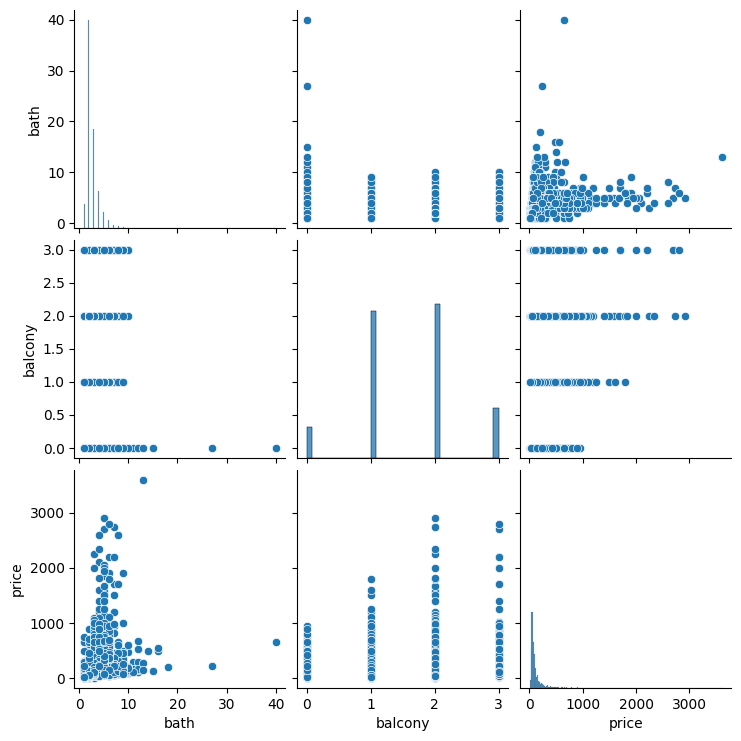

In [11]:
sns.pairplot(df_eda)

In [12]:
num_vars = df_eda.select_dtypes(include = ['float']).columns

<Axes: >

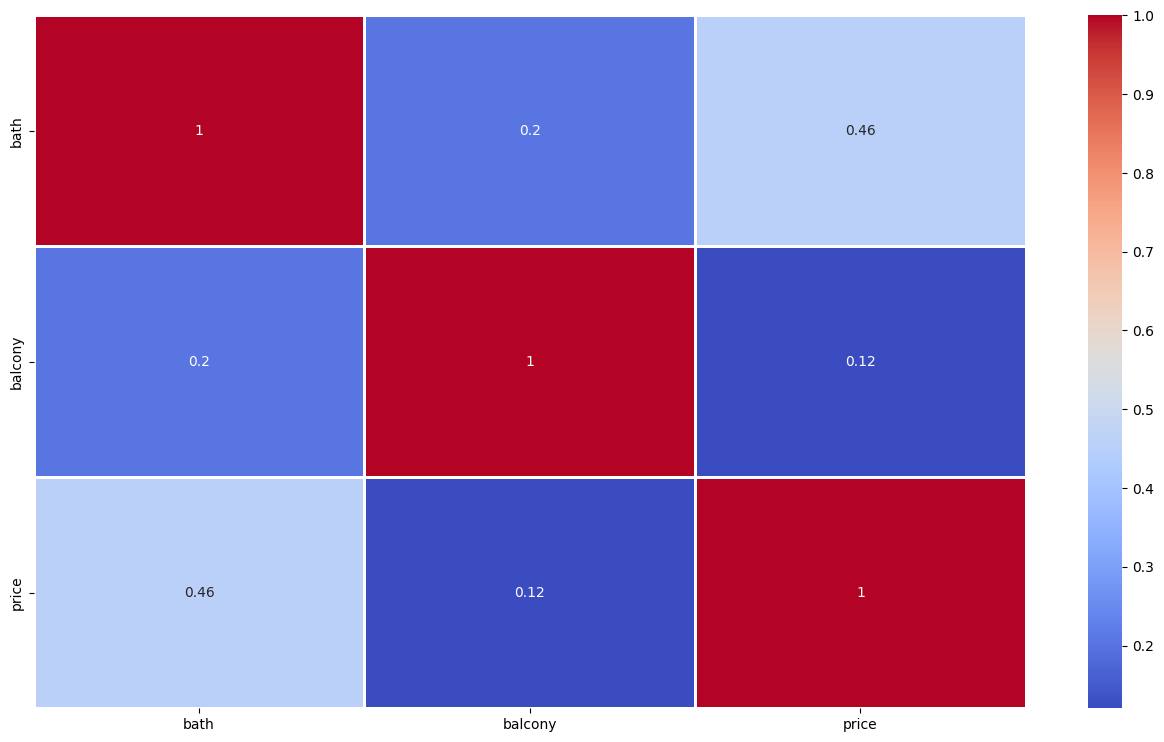

In [13]:
plt.figure(figsize = (16,9))
sns.heatmap(df_eda[num_vars].corr(), cmap = "coolwarm", annot = True, linewidth = 2)
# ở phiên bản mới của pandas không tự động bỏ qua các cột object nữa 
# nếu chuyền nguyên df_eda sẽ có lỗi không thể chuyển từ string sang float

In [14]:
df_eda.isnull().sum()
# is null trả về các giá trị true false nếu như ô hiện tại là null hoặc not null
# sum() mặc định tính tổng theo các hàng tương tự với axis = 0

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [15]:
df_eda.isnull().mean()* 100 # tỉ lệ null của các thuộc tính
# phương thức mean() sử dụng với 1 dataframe tạo ra 1 series với id là các tên các cột và giá trị là mean

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

Ta có thể bỏ đi các cột có số lượng null cao bất thường
* có thể thấy hơn 40% của society là null nên có thể bỏ đi cột này

In [16]:
df2 = df_eda.drop(columns = ['society'])
df2.shape

(13320, 8)

In [17]:
# xử lí các giá trị null của balcony (ở đây số giá trị null của balcony chưa đến 10% khá ít nên có thể thay thế bằng giá trị khác)
# trong trường hợp có nhiều giá trị null, thì null nên là 1 nhóm mới
df2['balcony'].value_counts()

balcony
2.0    5113
1.0    4897
3.0    1672
0.0    1029
Name: count, dtype: int64

In [18]:
# vì balcony có tập giá trị rời rạc nên có thể fillna bằng mode của nó
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mode()[0])
df2.isnull().sum()

area_type        0
availability     0
location         1
size            16
total_sqft       0
bath            73
balcony          0
price            0
dtype: int64

In [19]:
df2.shape

(13320, 8)

ta nhận thấy tỉ lệ giá trị null còn lại là rất bé so với kích thước của df2 nên có thể bỏ hẳn đi.
trong các trường hợp mà không thể đặt bừa giá trị thì cũng có thể bỏ đi ví dụ như (cccd hoặc là location như trong ví dụ trên)

In [20]:
df3 = df2.dropna()
df3.shape

(13246, 8)

In [21]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
#cho phép hiển thị tất cả các cột và hàng 

In [22]:
for i in df3['total_sqft'].unique():
    print(i)

1056
2600
1440
1521
1200
1170
2732
3300
1310
1020
1800
2785
1000
1100
2250
1175
1180
1540
2770
600
1755
2800
1767
510
1250
660
1610
1151
1025
2100 - 2850
1075
1760
1693
1925
700
1070
1724
1290
1143
1296
1254
1330.74
970
1459
800
869
1270
1670
2010
1185
1600
1500
1407
840
4395
845
5700
1160
3000
1140
1220
1350
1005
500
1358
1569
1240
2089
1206
1150
2511
460
4400
1660
1326
1325
1499
1665
708
1060
710
1450
2894
1330
2502
650
2400
1007
966
1630
1640
782
1260
1413
1116
1530
3700
2497
1436
276
1427
2061
3067 - 8156
2650
1282
1050
945
950
1870
880
1535
1360
1042 - 1105
1280
5000
3050
1563.05
1167
4000
1828
890
1612
1034
1710
957
2795
1125
1735
2050
3750
1063
1904
4200
2000
1145 - 1340
1425
1470
1300
450
1152
1550
400
705
770
1242
1700
2144
1704
1846
1340
1015 - 1540
1327
1186
1783
1400
980
1285
912
1225
1909
1359
1207
1736
2850
1595
1798
1475
1580
1295
3600
589
1415
1787
984
2405
1080
1900
805
1153
1148
1110
1933
3500
645
1644
910
1577
4050
2420
900
1108
3045
2900
1162
1035
1464
1866
1804
913

In [23]:
# chuyển total_sqft thành float
total_sqft_float = []
for i in df3['total_sqft']:
    try:
        total_sqft_float.append(float(i))
    except:
        try:
            tmp = []
            tmp = i.split('-')
            total_sqft_float.append((float(tmp[0])+float(tmp[-1])/2))
        except:
            total_sqft_float.append(np.nan)

In [24]:
df3.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [25]:
# vì trước đây đã bỏ đi 1 số hàng chứa null nên index của df3 đang không liên tục
df4 = df3.reset_index(drop = True)
# drop = True để không giữ lại cột index cũ làm 1 cột mới 

In [26]:
df5 = df4.copy()
df5['total_sqft_float'] = total_sqft_float

In [27]:
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


In [28]:
df5.isnull().sum()

area_type            0
availability         0
location             0
size                 0
total_sqft           0
bath                 0
balcony              0
price                0
total_sqft_float    46
dtype: int64

In [29]:
df6 = df5.dropna()
df6.shape

(13200, 9)

In [30]:
df6.info()

<class 'pandas.DataFrame'>
Index: 13200 entries, 0 to 13245
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  str    
 1   availability      13200 non-null  str    
 2   location          13200 non-null  str    
 3   size              13200 non-null  str    
 4   total_sqft        13200 non-null  str    
 5   bath              13200 non-null  float64
 6   balcony           13200 non-null  float64
 7   price             13200 non-null  float64
 8   total_sqft_float  13200 non-null  float64
dtypes: float64(4), str(5)
memory usage: 1.0 MB


In [31]:
df6['size'].value_counts().to_frame()

,count
size,
2 BHK,5192
3 BHK,4277
4 Bedroom,816
4 BHK,574
3 Bedroom,541
1 BHK,527
2 Bedroom,325
5 Bedroom,293
6 Bedroom,190


In [32]:
size_int = []
for i in df6['size']:
    tmp = []
    tmp = i.split(' ')
    try:
        size_int.append(int(tmp[0]))
    except:
        size_int.append(np.nan)
        print(f"Notice {i}")

In [33]:
# vì df6 đã bỏ đi các hàng có null ở df5 đánh lại index
df6 = df6.reset_index(drop = True)

In [34]:
df7 = df6.copy()
df7['bhk'] = size_int
df7.shape

(13200, 10)

In [35]:
df7.tail()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
13195,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.0,231.0,3453.0,5
13196,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,2.0,400.0,3600.0,4
13197,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.0,1141.0,2
13198,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4689,4.0,1.0,488.0,4689.0,4
13199,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,550,1.0,1.0,17.0,550.0,1


<Axes: xlabel='total_sqft_float'>

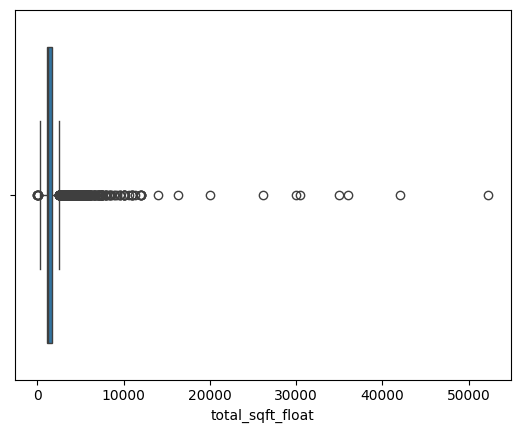

In [36]:
sns.boxplot(x = df7['total_sqft_float'])

iqr là hộp ở giữa q1 là đầu của iqr q3 là phần cuối của iqr, râu ở ngoài cùng bên trái có thể là giá trị lớn hơn hoặc bằng q1-1,5*iqr, râu ở ngoài cùng là giá trị lớn nhất trong tập dữ liệu bé hơn hoặc bằng q3+1,5*iqr, các giá trị nằm ngoài 2 râu là các outliner (ngoại lai)

(200.0, 1000.0)

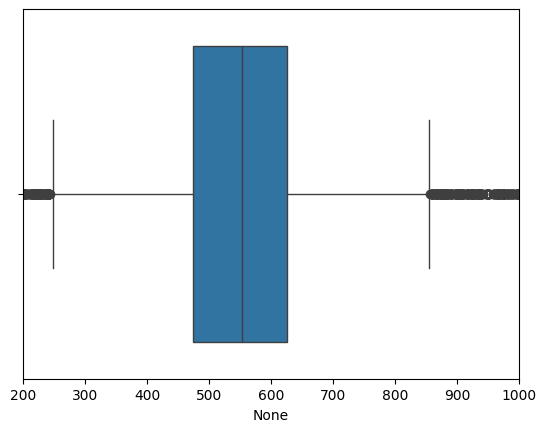

In [37]:
sns.boxplot(x = df7['total_sqft_float']/df7['bhk'])
plt.xlim(200,1000)
# xem xét boxplot của trung bình diện tích của 1 phòng để tìm các outliner
# ta có được râu bên trái từ tầm 240 đổ xuống có thể bỏ đi vì thường là lỗi logic có thể là do nhập sai dữ liệu
# xem xét việc bỏ đi các outliner lớn hơn râu bên phải vì có thể đó là các căn hộ sang trọng

In [38]:
df7['total_sqft_float'][df7['total_sqft_float']>=10000]

404      12000.0
435      11890.0
598      12000.0
665      35000.0
798      10961.0
1218     14000.0
1867     52272.0
2589     11338.0
2592     30000.0
3060     12000.0
3568     10000.0
4263     10000.0
4881     12000.0
5343     42000.0
5417     36000.0
7166     26136.0
7238     11000.0
7771     10200.0
7862     20000.0
8078     11000.0
9144     10961.0
9447     10000.0
9974     10030.0
10203    10624.0
10642    10000.0
12355    16335.0
12868    30400.0
Name: total_sqft_float, dtype: float64

In [39]:
# ta sẽ xem xét diện tích trung bình 1 phòng của các căn nhà
# công thức là tổng diện tích ft chia cho số phòng
df7[df7['total_sqft_float']/df7['bhk']<250].shape

(612, 10)

In [40]:
(df7['total_sqft_float']/df7['bhk']).mean()

np.float64(577.1261144830384)

In [41]:
df8 = df7[df7['total_sqft_float']/df7['bhk']>=350]
df8.shape
# đoạn này chú ý không hiểu sao tài liệu lấy 350 đáng lẽ nên lấy giá trị tầm khoảng sau râu bên phải 1 chút

(12107, 10)

In [42]:
# thêm cột trung bình giá của 1 feet vuông
# price có đơn vị là Lakh (đm dataset đ có note gì) nhân thêm 1e5 để ra đơn vị rupees
df8['price_per_sqft'] = df8['price']*100000/df8['total_sqft_float']
df8.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0,2,4250.000000


In [43]:
df8['price_per_sqft'].describe()

count     12107.000000
mean       6165.741880
std        4027.230938
min         267.829813
25%        4176.687383
50%        5245.901639
75%        6789.524733
max      176470.588235
Name: price_per_sqft, dtype: float64

Quan sát các outliner của các feature

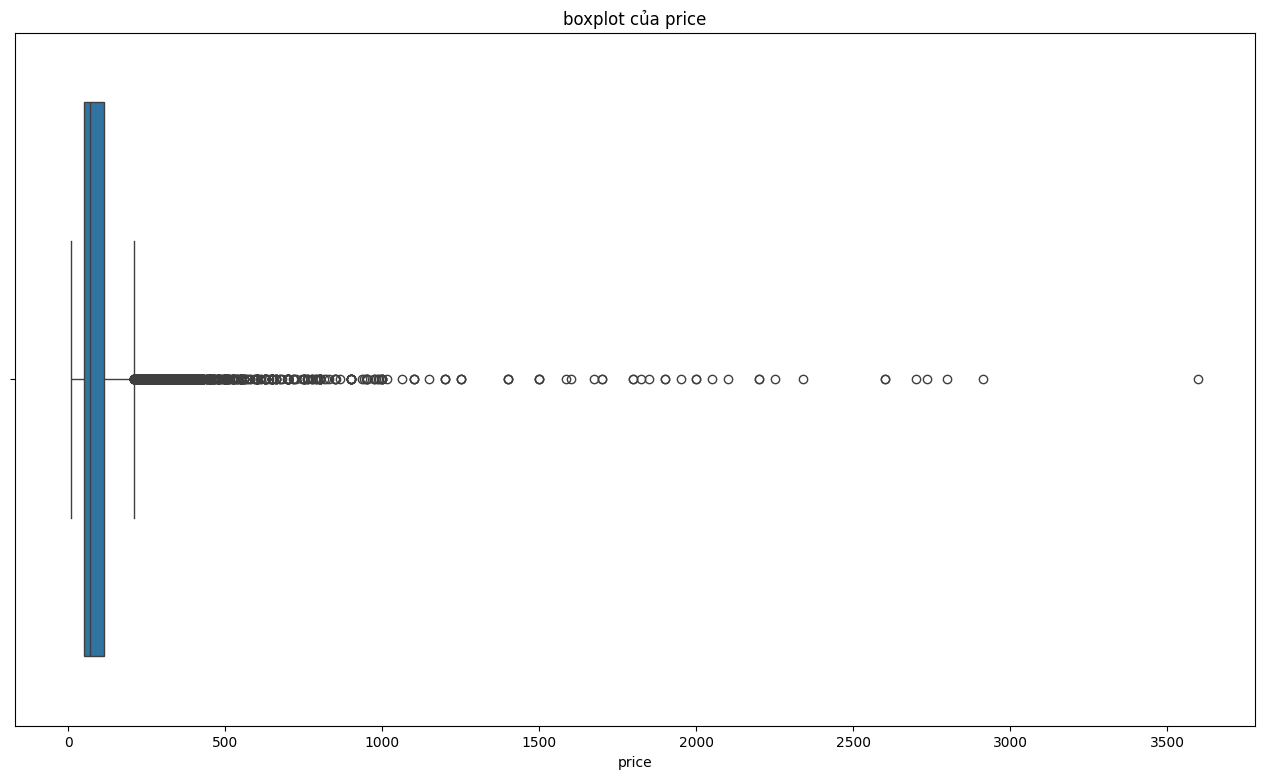

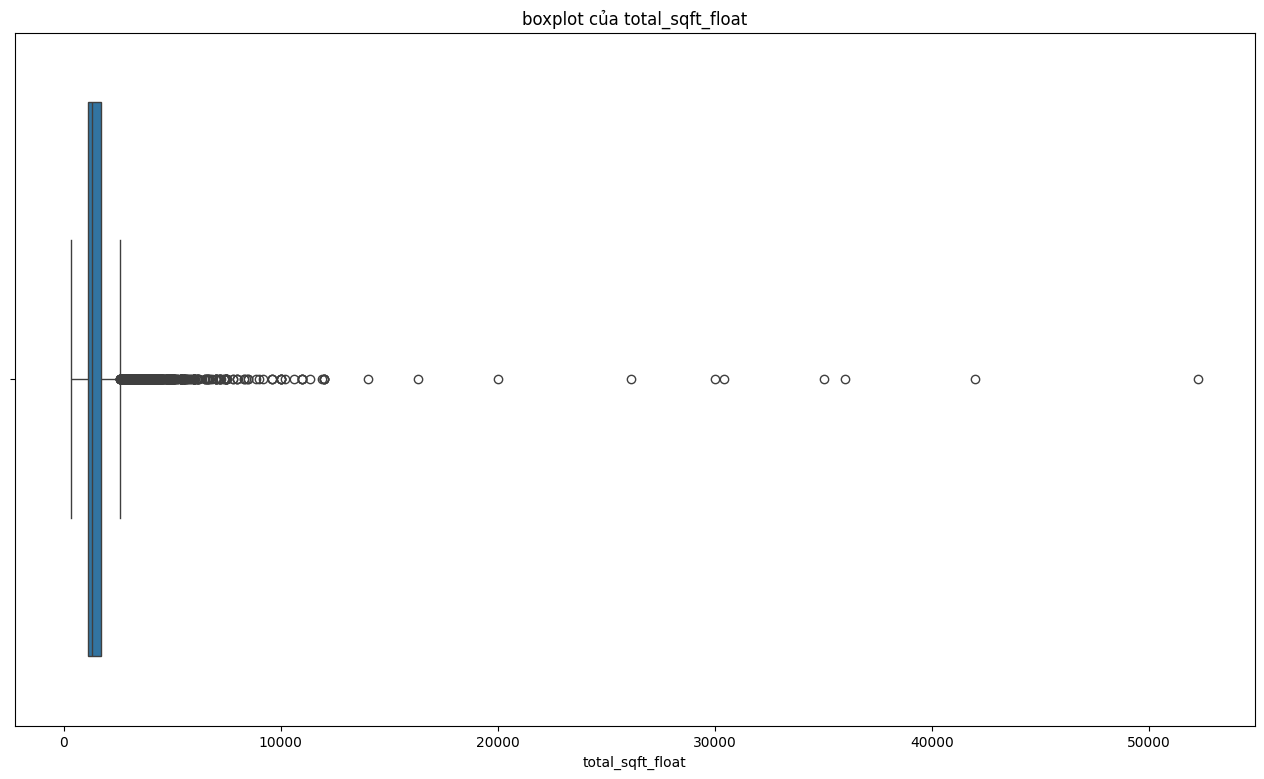

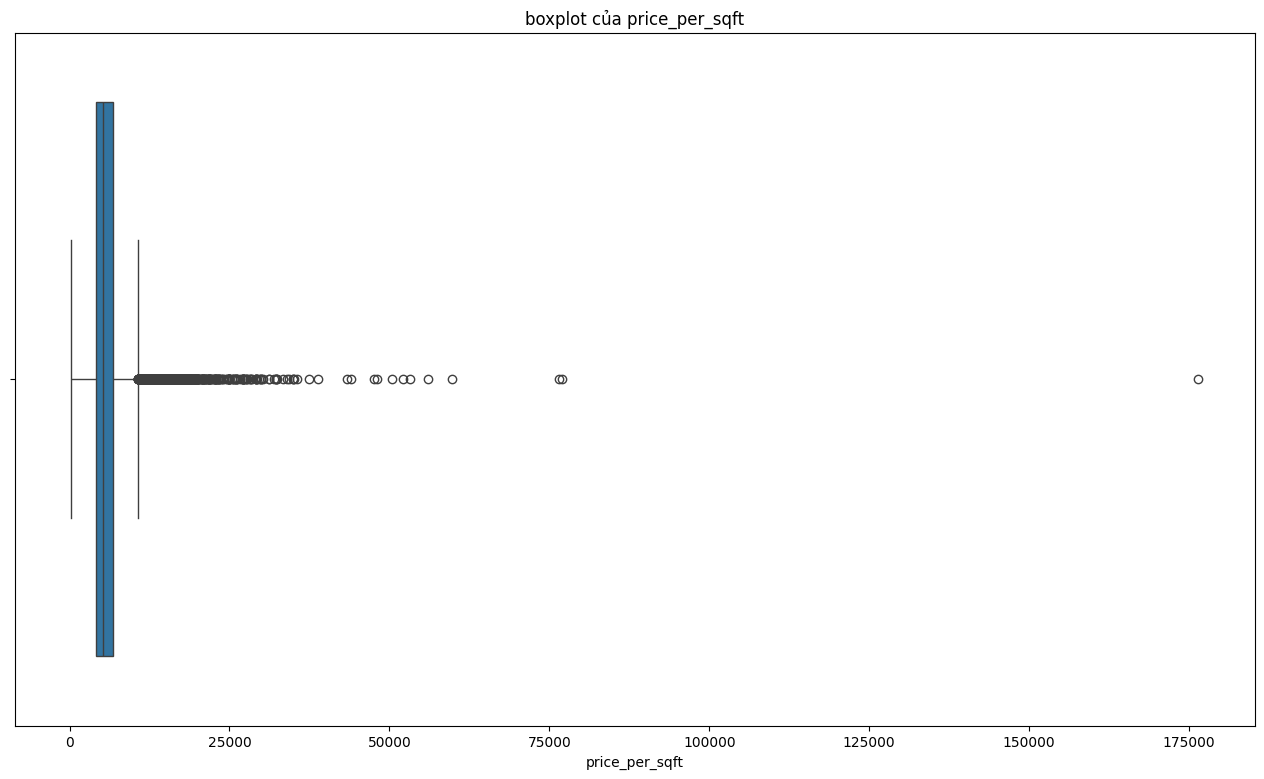

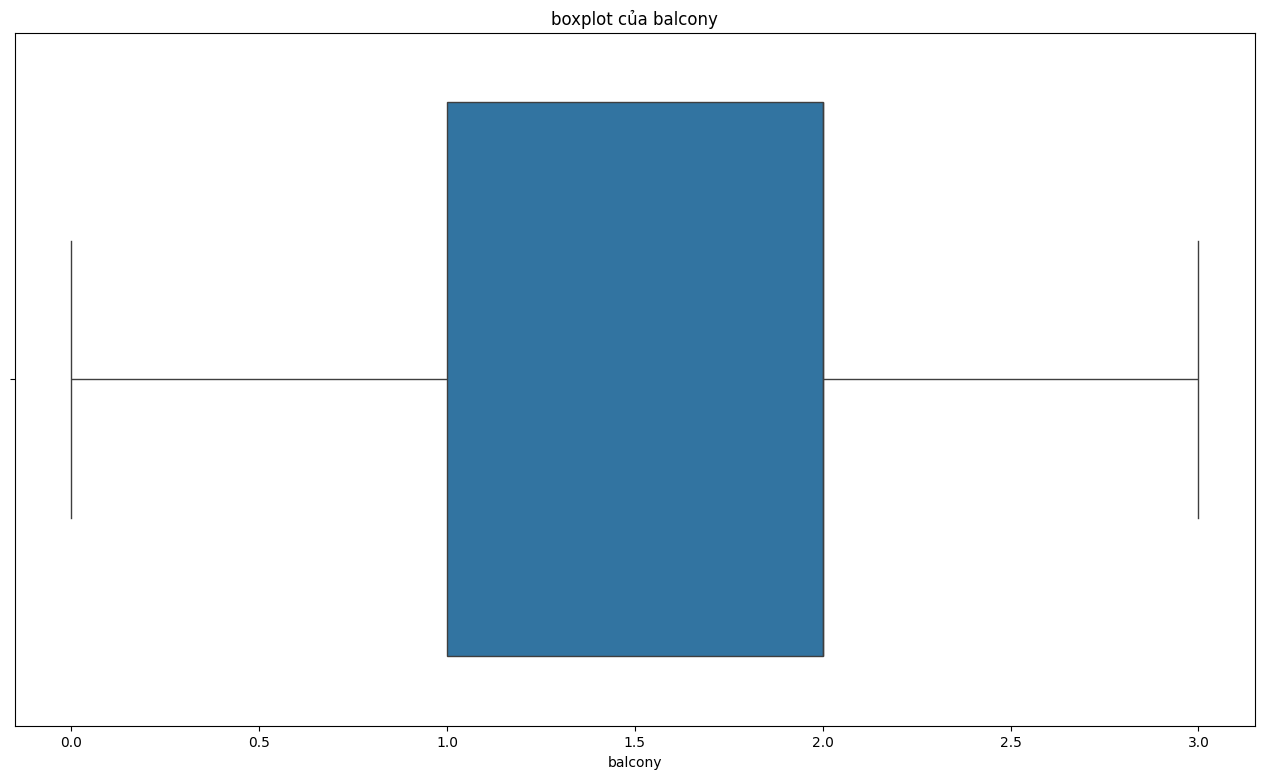

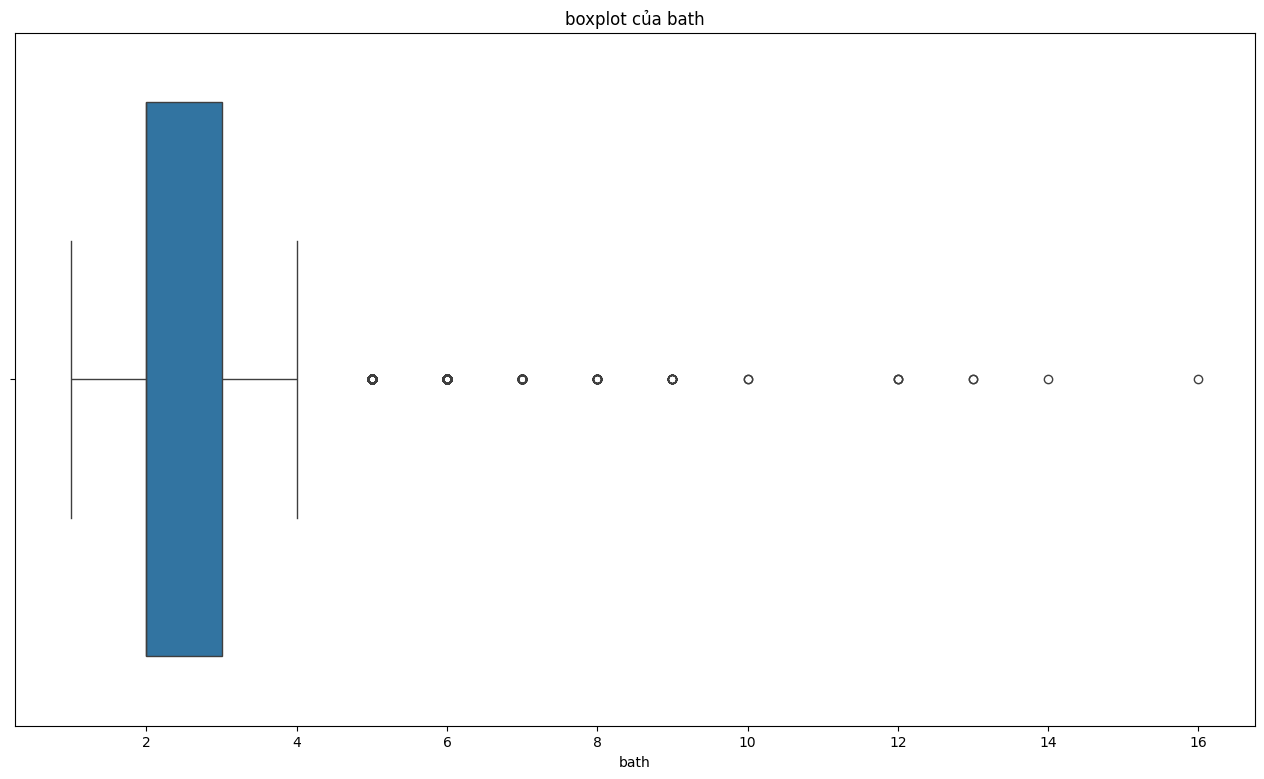

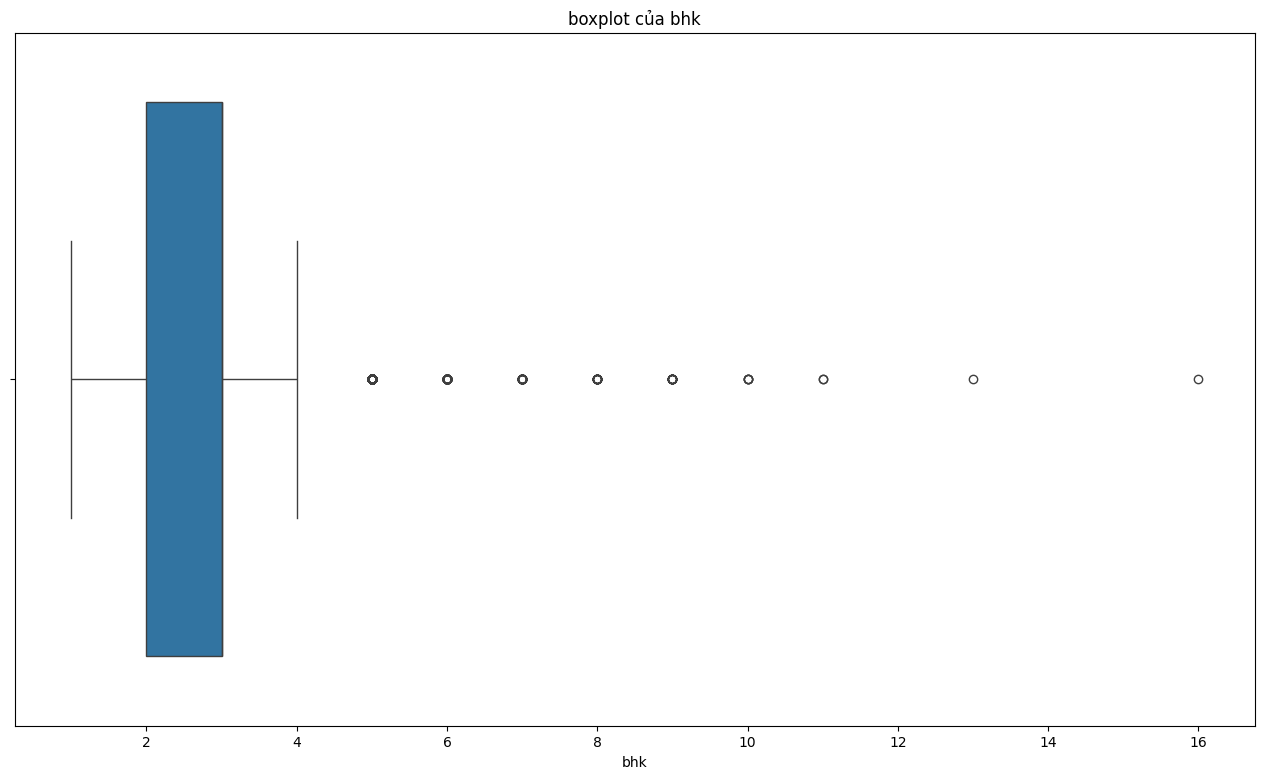

In [44]:
vars = ['price', 'total_sqft_float', 'price_per_sqft', 'balcony', 'bath', 'bhk']
for i in vars:
    plt.figure(figsize = (16,9))
    plt.title(f'boxplot của {i}')
    sns.boxplot(x = df8[i])

In [45]:
# hàm để bỏ đi các điểm dữ liệu có price per sqft .. dựa trên vị trí location
# sử dụng group by và transform để tạo cột mới tính theo mean và std group by bởi location
df8['mean_price_per_sqft_location'] = df8.groupby('location')['price_per_sqft'].transform('mean')
df8['std_price_per_sqft_location'] = df8.groupby('location')['price_per_sqft'].transform('std')
df8.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft,mean_price_per_sqft_location,std_price_per_sqft_location
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0,2,3699.810606,3778.329506,2166.453172
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0,4,4615.384615,4468.307828,931.340254
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0,3,4305.555556,4177.369504,795.695191
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0,3,6245.890861,6613.525331,714.882318
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0,2,4250.000000,5483.294629,1606.573738


In [46]:
# hàm để bỏ đi các điểm dữ liệu có price per sqft .. dựa trên vị trí location
def remove_pps_outliners(df):
    return df[(df['price_per_sqft']>=df['mean_price_per_sqft_location']-df['std_price_per_sqft_location']) & (df['price_per_sqft']<=df['mean_price_per_sqft_location']+df['std_price_per_sqft_location'])]
df9 = remove_pps_outliners(df8)

In [47]:
df9.shape
# lúc này trong df9 có thêm 2 cột để lưu mean và std ứng với các location

(9232, 13)

In [48]:
df9.columns


Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price', 'total_sqft_float', 'bhk', 'price_per_sqft',
       'mean_price_per_sqft_location', 'std_price_per_sqft_location'],
      dtype='str')

In [49]:
# xem xét các điểm outliner liên quan đến giá phòng trung bình
# đầu tiên là cứ đánh index lại df9
df9 = df9.reset_index(drop = True)
df9.tail()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft,mean_price_per_sqft_location,std_price_per_sqft_location
9227,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,1345,2.0,1.0,57.0,1345.0,3,4237.918216,4177.369504,795.695191
9228,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,1715,3.0,3.0,112.0,1715.0,3,6530.612245,6484.825743,1011.938956
9229,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.0,231.0,3453.0,5,6689.834926,6141.141043,3260.860871
9230,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,2.0,400.0,3600.0,4,11111.111111,10244.109129,2348.631959
9231,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,550,1.0,1.0,17.0,550.0,1,3090.909091,3913.220411,999.908172


<Axes: xlabel='None'>

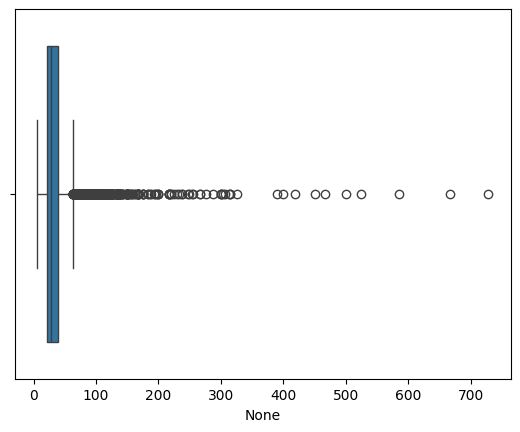

In [50]:
# phác boxplot của giá nhà trung bình của 1 phòng
sns.boxplot(x = df9['price']/df9['bhk'])


In [51]:
df9[df9['price']/df9['bhk']>63].shape

(656, 13)

In [52]:
# có thể outliner là phòng quá rẻ trong khi có quá nhiều phòng
# giá phòng không nằm trong khoảng mean_giá_phòng trung bình -std, mean+std theo locatino
df9.columns
df9 = df9.drop(columns = ['mean_price_per_sqft_location', 'std_price_per_sqft_location'])
# bỏ đi các cột vừa thêm vào ở bước trước để tính mean và std của pricepersqft

In [53]:
def remove_bhk_outliners(df):
    df['price_room'] = df['price']*100000/df['bhk']
    df['mean_price_room_location'] = df.groupby('location')['price_room'].transform('mean')
    df['std_price_room_location'] = df.groupby('location')['price_room'].transform('std')
    return df[(df['price_room']>=df['mean_price_room_location'] - df['std_price_room_location']) & (df['price_room']>=df['mean_price_room_location'] - df['std_price_room_location'])]
df10 = remove_bhk_outliners(df9)
df10.shape

(8237, 14)

In [54]:
df10 = df10.drop(columns = ['price_room','mean_price_room_location','std_price_room_location'])
df10 = df10.reset_index(drop = True)
df10.tail()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
8232,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,1345,2.0,1.0,57.0,1345.0,3,4237.918216
8233,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,1715,3.0,3.0,112.0,1715.0,3,6530.612245
8234,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.0,231.0,3453.0,5,6689.834926
8235,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,2.0,400.0,3600.0,4,11111.111111
8236,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,550,1.0,1.0,17.0,550.0,1,3090.909091


<Axes: xlabel='bath'>

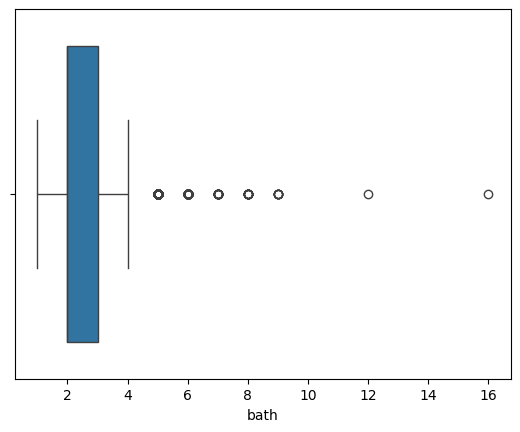

In [57]:
# bỏ đi các outliner khi xét bathroom

sns.boxplot(x = df10['bath'])

In [61]:
df10[df10['bath']==16].shape

(1, 11)

In [63]:
# giả sử mỗi phòng đều có 1 nhà tắm thì số nhà tắm tối đa là số phòng, có thể dư thêm 1 nhà tắm
# dataset không có mô tả gì cũng không rõ bath là gì có thể là số nhà tắm
df11 = df10[df10['bath']<df10['bhk']+2]
df11.shape

(8148, 11)

<Axes: xlabel='bath'>

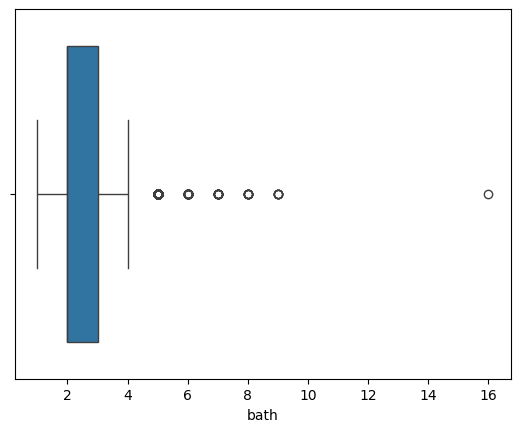

In [65]:
sns.boxplot(x = df11['bath'])

Bath có ít outliner hơn khi bỏ đi các instance liên quan đến số phòng và số nhà tắm

In [ ]:
# bỏ đi các trường không cần thiết
remove_feature = ['area_type', 'availability','location','size','total_sqft']
# total sqft đã có dạng chuẩn float rồi
# size đã có trường bhk rồi
df11[remove_feature].head()

,area_type,availability,location,size,total_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440
3,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200
4,Super built-up Area,Ready To Move,Whitefield,2 BHK,1170


In [70]:
df12 = df11.drop(columns = remove_feature)
df12.head()

,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,2.0,1.0,39.07,1056.0,2,3699.810606
1,5.0,3.0,120.00,2600.0,4,4615.384615
2,2.0,3.0,62.00,1440.0,3,4305.555556
3,2.0,1.0,51.00,1200.0,2,4250.000000
4,2.0,1.0,38.00,1170.0,2,3247.863248


In [72]:
clean_data_dir = os.path.join(base_dir,'Ex2','Bangalore_House_Price_data','clean_data.csv')
df12.to_csv(clean_data_dir, index = False)

In [ ]:
def plot_scatter_chart(df, location):
    plt.figure(figsize = (16,9))
    plt.title(f"{location}")
    price_arr_2bhk = []
    price_arr_3bhk = []
    total_sqft_float_arr_2bhk = []
    total_sqft_float_arr_3bhk = []
    price_arr_2bhk = df[(df['bhk']==2) & (df['location']==location)]['price'] # chú ý trong pandas toán tử & ưu tiên cao hơn toán tử == nên phải dùng dấu ngoặc đơn
    price_arr_3bhk = df[(df['bhk']==3) & (df['location']==location)]['price']
    total_sqft_float_arr_2bhk = df[(df['bhk']==2) & (df['location']==location)]['total_sqft_float']
    total_sqft_float_arr_3bhk = df[(df['bhk']==3) & (df['location']==location)]['total_sqft_float']
    plt.scatter(price_arr_2bhk, total_sqft_float_arr_2bhk, marker = '+', color = 'r', label = '2 BHK')
    plt.scatter(price_arr_3bhk, total_sqft_float_arr_3bhk, marker = 'o', color = 'b', label = '3 BHK')
    plt.xlabel('price')
    plt.ylabel('total_sqft_float')
    plt.legend()

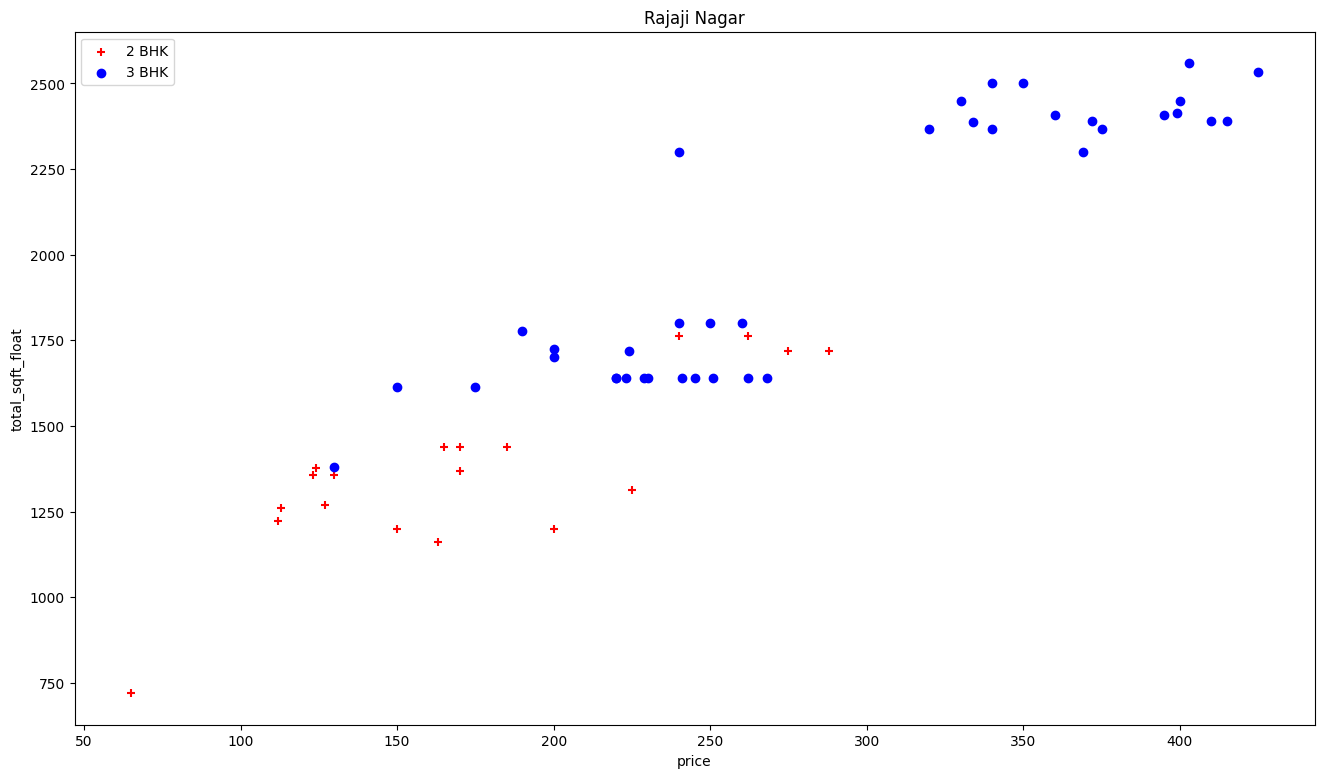

In [92]:
plot_scatter_chart(df9, 'Rajaji Nagar')

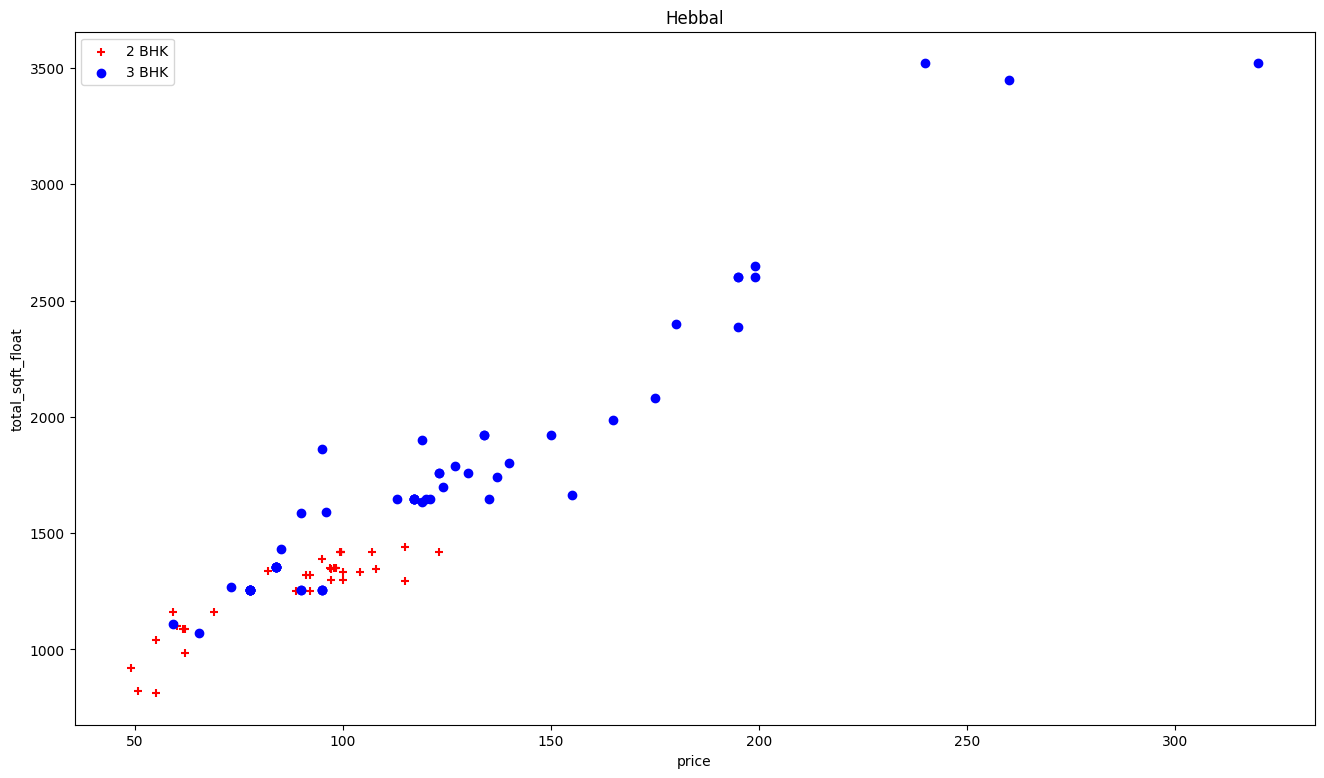

In [93]:
plot_scatter_chart(df9,'Hebbal')